In [1]:
%load_ext autoreload
%autoreload 2


from coralshift.utils import file_ops
from coralshift.dataloading import get_data
from coralshift.plotting import spatial_plots
from coralshift import functions_creche

import warnings
warnings.filterwarnings(action="ignore", category=RuntimeWarning)

config_info = file_ops.read_yaml("/maps/rt582/coralshift/runs/config_files/config_test.yaml")

import xarray as xa

In [3]:
curacao_config_info = file_ops.read_yaml("/maps/rt582/coralshift/runs/config_files/curacao.yaml") 

curacao_ds = get_data.ReturnRaster(dataset="gebco", config_info=curacao_config_info).get_raw_raster()


Loading gebco xarray across [11, 13] latitudes & [-67.5, -71.5] longitudes from /maps-priv/maps/rt582/coralshift/data/bathymetry/gebco/gebco_2023_n35.0_s0.0_w-100.0_e-55.0.nc.


In [ ]:
    ax.add_feature(
        cfeature.NaturalEarthFeature(
            default_cartopy_dict["category"],
            default_cartopy_dict["name"],
            default_cartopy_dict["scale"]),
            default_cartopy_dict["edgecolor"],
            default_cartopy_dict["facecolor"],
            default_cartopy_dict["linewidth"],
            default_cartopy_dict["alpha"],
        )
    
###
    ax.add_feature(
        cfeature.NaturalEarthFeature(
            "physical",
            "land",
            "10m",
            edgecolor="black",
            facecolor=(0, 0, 0, 0), # "none"
            linewidth=0.5,
            alpha=0.3,
        )
    )

(<Figure size 3000x3000 with 2 Axes>,
 <GeoAxes: title={'center': 'Curacao elevation'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x7f1900410290>)

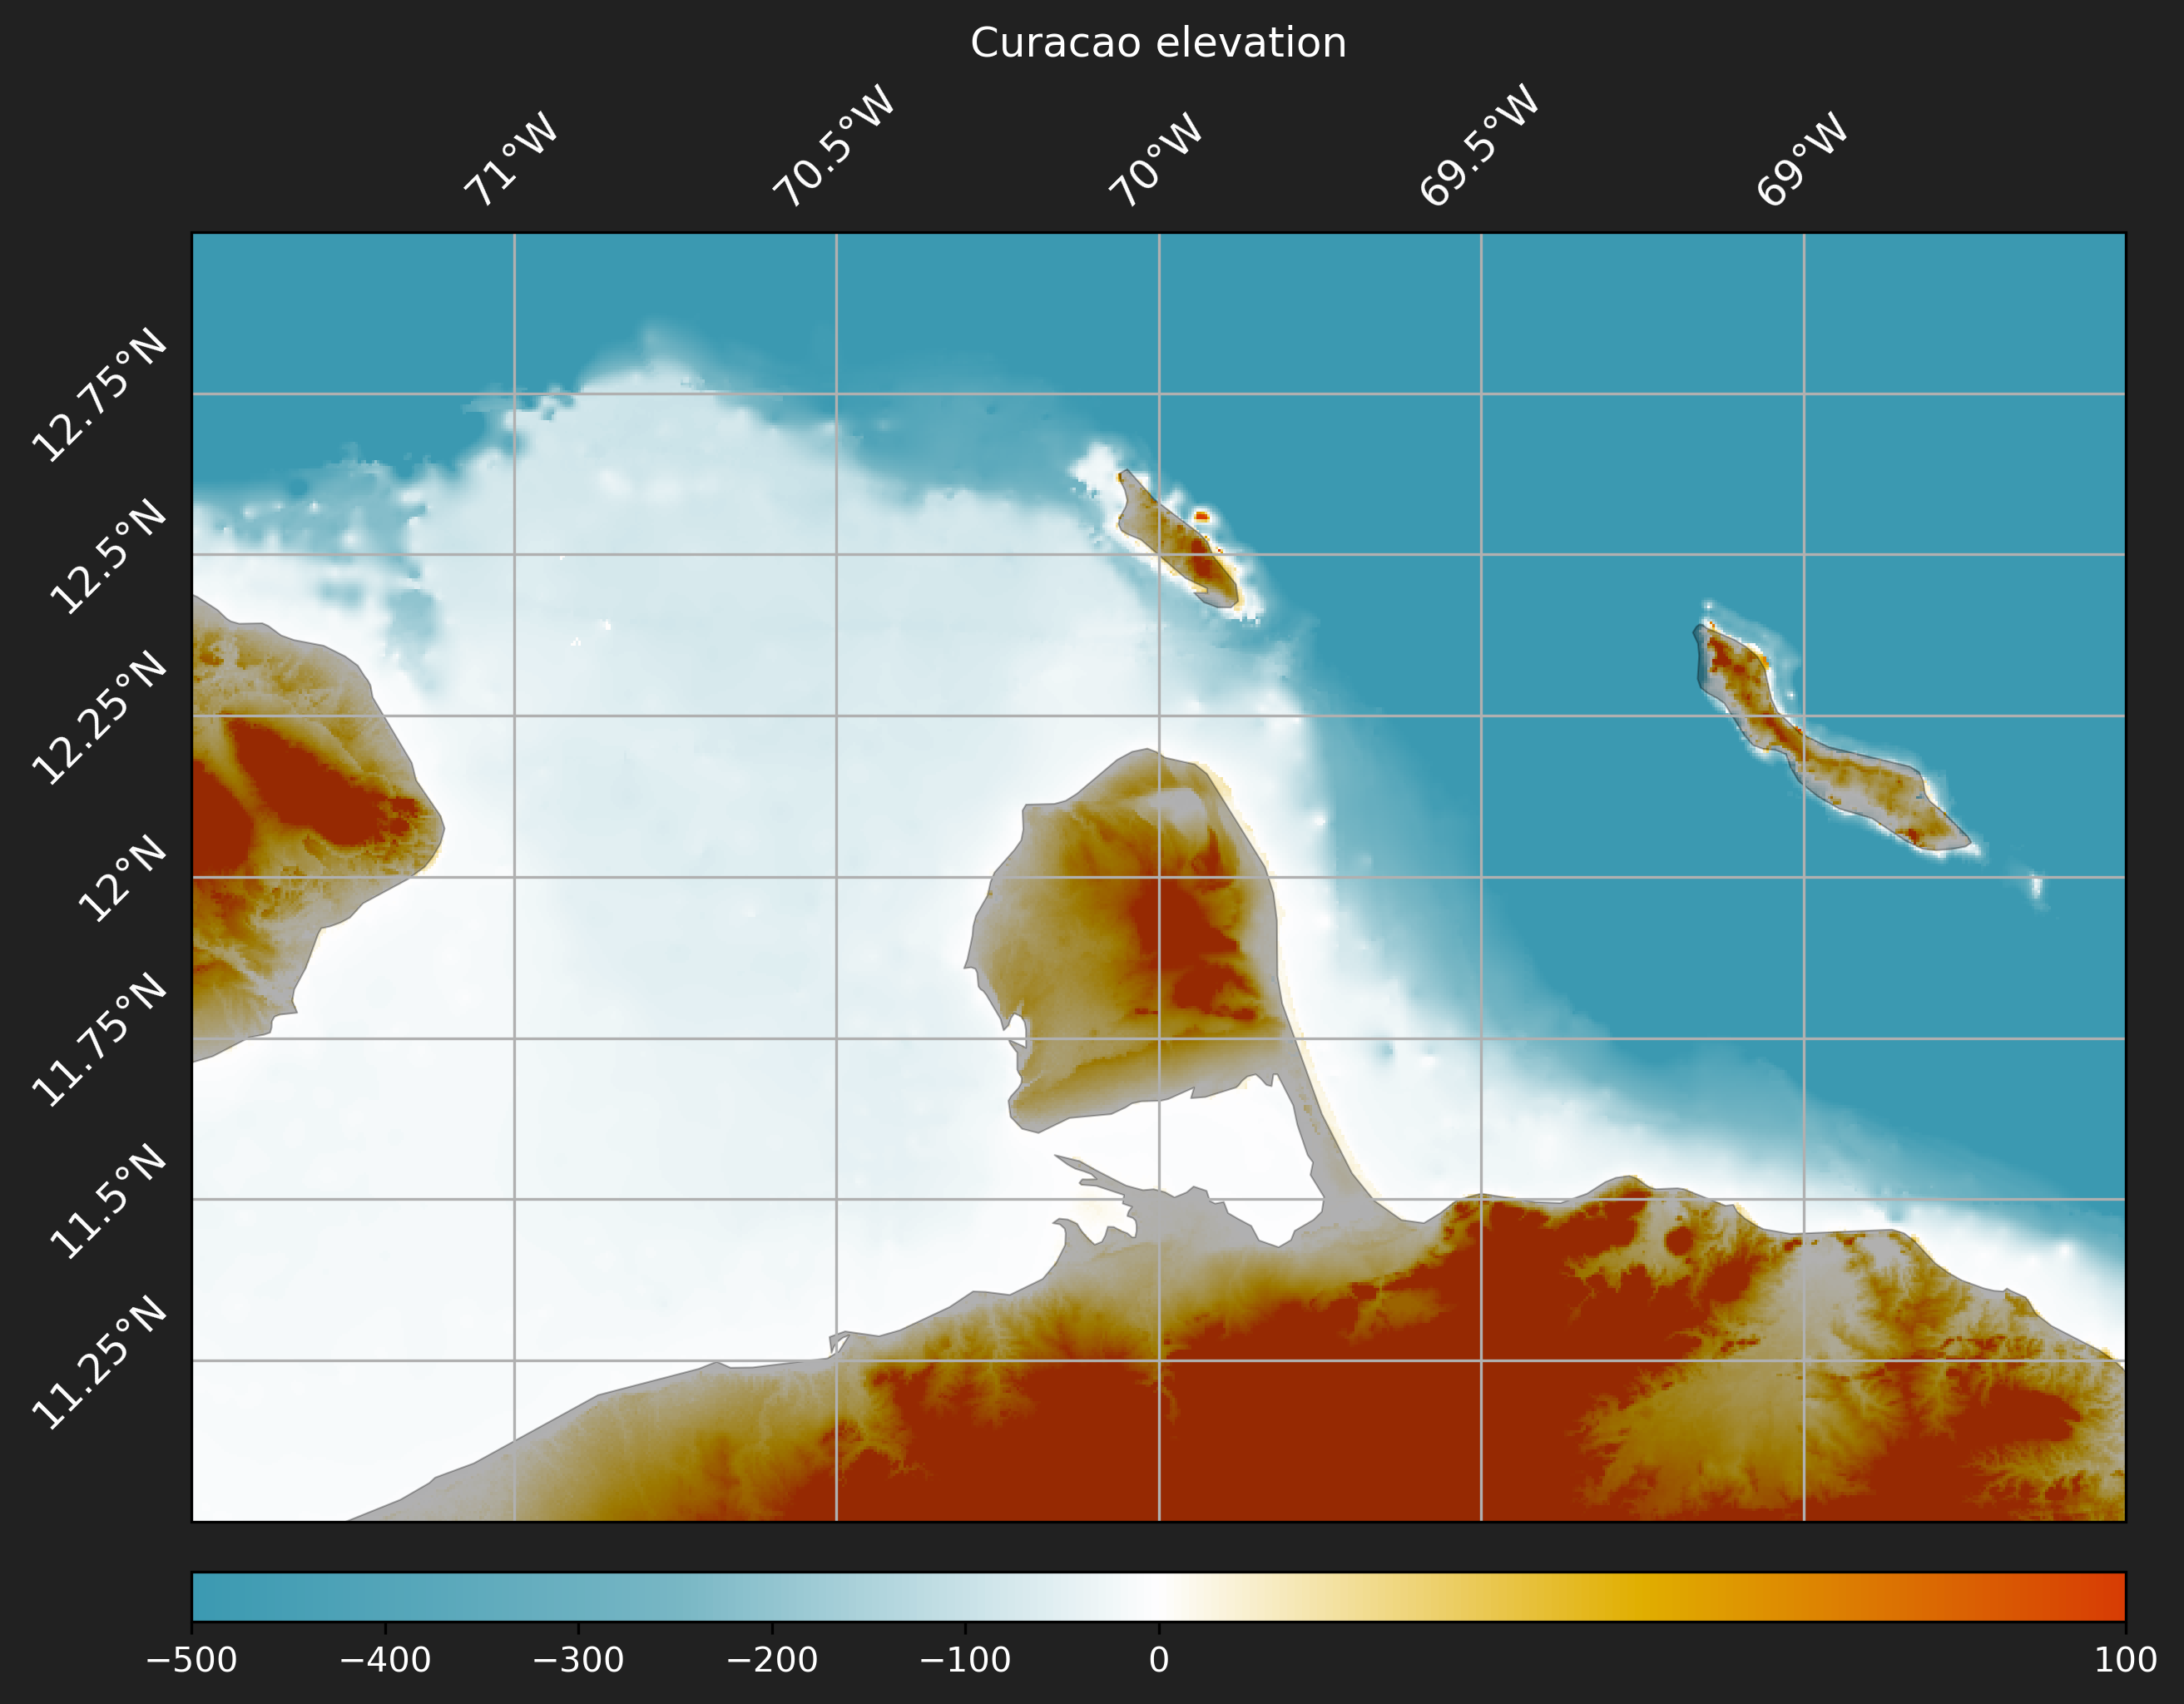

In [92]:
spatial_plots.plot_spatial(curacao_ds["elevation"].sel(longitude=slice(-71.5,-68.5)), cmap_type="div", val_lims=[-500, 100], presentation_format=True, title="Curacao elevation", labels=["l", "b"], cbar_dict={"orientation": "horizontal"})

(<Figure size 3000x3000 with 2 Axes>,
 <GeoAxes: title={'center': 'elevation at 0.0042° (~452 m) resolution'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x7fc911758490>)

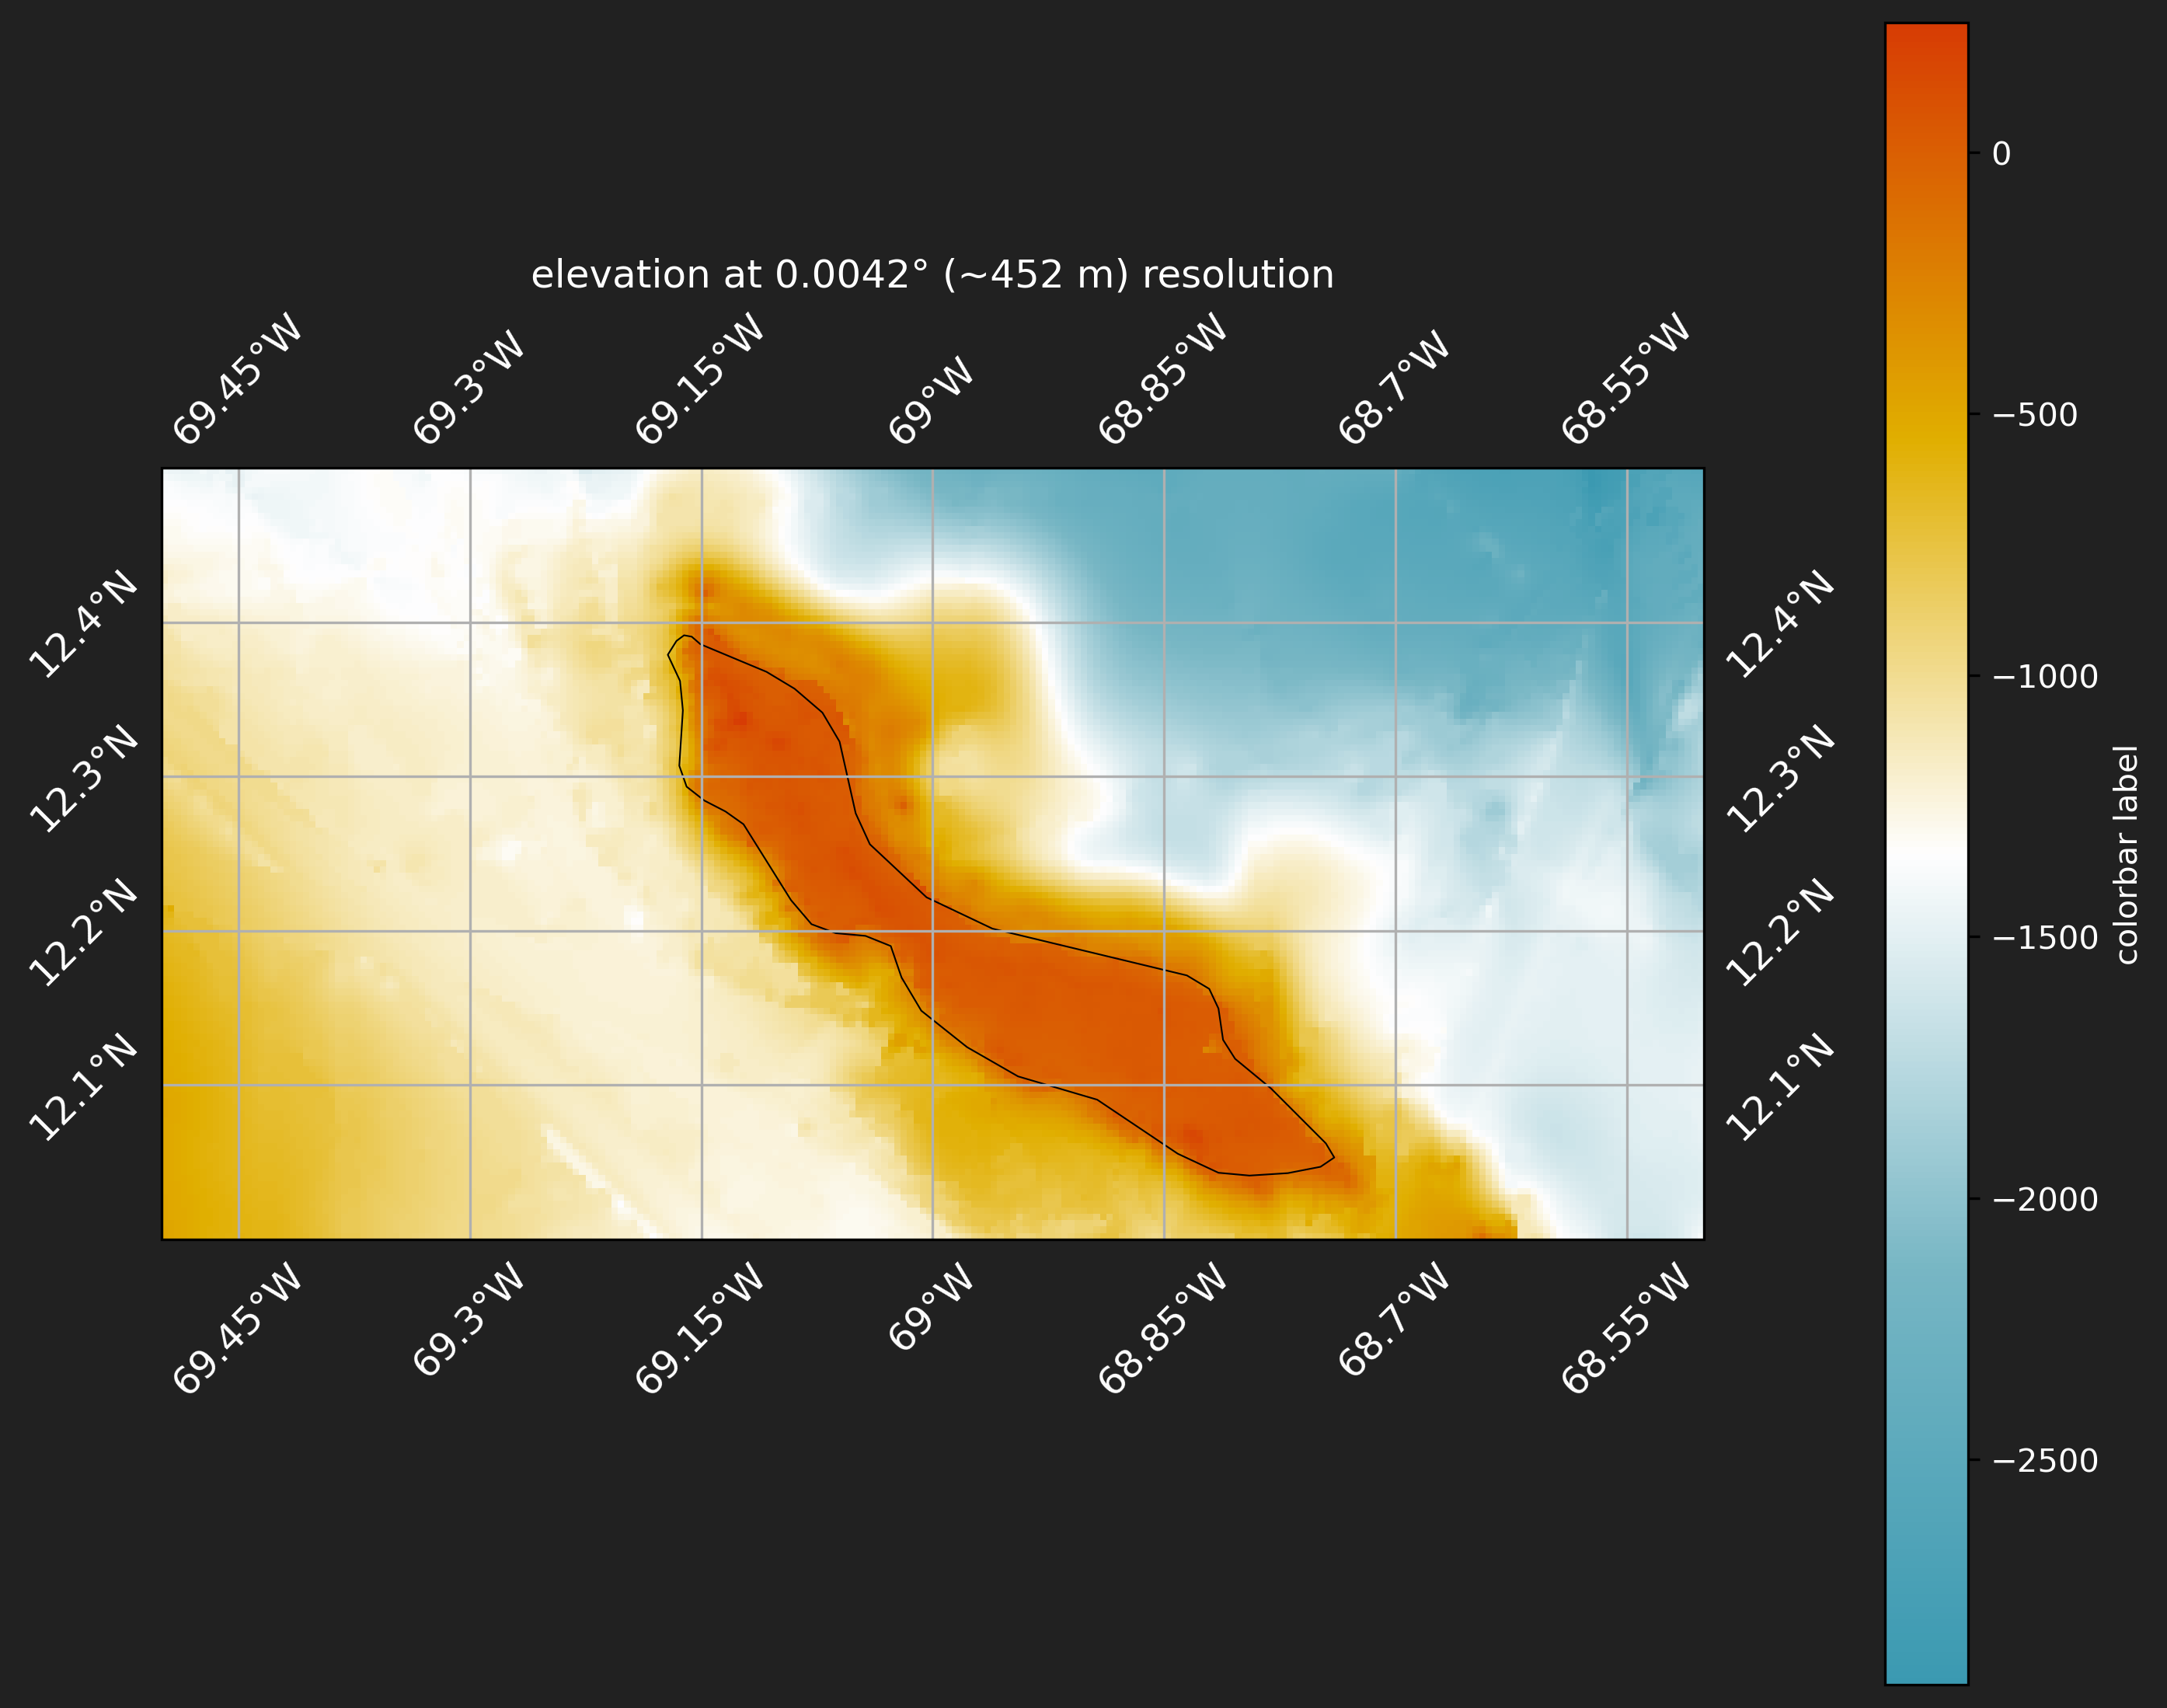

In [17]:
spatial_plots.plot_spatial(curacao_ds["elevation"].sel(latitude=slice(12, 12.5), longitude=slice(-69.5, -68.5)), presentation_format=True, cbar=True, cmap_type="div")

In [ ]:
spatial_plots.plot_spatial(curacao_ds["UNEP_GDCR"].sel(latitude=slice(12, 12.5), longitude=slice(-69.5, -68.5)), presentation_format=True, cbar=False)

In [ ]:
spatial_plots.plot_spatial(curacao_ds["UNEP_GDCR"].sel(latitude=slice(10,14), longitude=slice(-71,-67)))

In [ ]:
config_info = file_ops.read_yaml("/maps/rt582/coralshift/runs/config_files/config_test.yaml")
ds = get_data.ReturnRaster(dataset="unep", config_info=config_info).return_raster()
ds["UNEP_norm"] = ds["UNEP_GDCR"] / ds["UNEP_GDCR"].max()
spatial_plots.plot_spatial(ds["UNEP_norm"].sel(latitude=slice(-13,-10), longitude=slice(142.5,144.5)), presentation_format=True, cbar=True)

In [68]:
# threshold UNEP_GDCR values above 0.01 to 1 and plot
ds['UNEP_GDCR_01'] = xa.where(ds['UNEP_norm'] >= 0.01, 1, 0)
ds['UNEP_GDCR_1'] = xa.where(ds['UNEP_norm'] >= 0.1, 1, 0)
ds['UNEP_GDCR_2-5'] = xa.where(ds['UNEP_norm'] >= 0.25, 1, 0)
ds['UNEP_GDCR_5'] = xa.where(ds['UNEP_norm'] >= 0.5, 1, 0)
# ds['UNEP_GDCR_5'] = xa.where(ds['UNEP_norm'] >= 0.5, 1, ds['UNEP_norm'])
# spatial_plots.plot_spatial(ds['UNEP_GDCR_01'].sel(latitude=slice(-13,-10), longitude=slice(142.5,144.5)), presentation_format=True, cbar=False)

In [ ]:
spatial_plots.plot_spatial(ds['UNEP_norm'].sel(latitude=slice(-13,-10), longitude=slice(143.25,144.25)), presentation_format=True, cbar=True, labels=[], title="")